In [41]:
using DataFrames
using Revise
using Newtrinos
using Newtrinos.osc

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

experiments = (
 
    dayabay = Newtrinos.dayabay.configure(physics),
);

par = Newtrinos.get_params(experiments)
p=merge(par, (r=1e-8,))

[ Info: Loading dayabay data


(N = 20.0, m₀ = 0.01, r = 1.0e-8, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.05, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [42]:
N=p.N
m0=p.m₀
r=p.r

1.0e-8

In [3]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2

In [8]:
f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
FinalUmatrix, h, eigenvalues = f1(p)

file_name_eigen="/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_pert9_NNM_NO_$N $r $m0.txt"

open(file_name_eigen, "w") do io
    for i in 1:length(eigenvalues)
        @printf(io, "%f\n", eigenvalues[i])
    end
end 

file_name_h="/home/sofialon/Newtrinos.jl/plots_fix/eigen/h_pert9_NNM_NO_$N $r $m0.txt"

open(file_name_h, "w") do io
    for i in 1:length(h)
        @printf(io, "%f\n", h[i])
    end
end 


In [43]:
#analytical eigenvalues first
m1,m2,m3=Newtrinos.osc.get_abs_masses(p)

eigen_analytical=[]


N=par.N
η=1+(1/N)
factor=((η-1) * 2^(1/(N-1)))^2
factorN= (0.5*(η-1)*(1+(N/(η-1))))^2


for i in 1:N
    eigenvalue_e =((2(i-1) + r)^2*m1^2/r^2)
    eigenvalue_mu=((2(i-1) + r)^2*m2^2/r^2)
    eigenvalue_t =((2(i-1) + r)^2*m3^2/r^2)

    if i==N
         eigenvalue_e =((2(i-1) + r)^2*m1^2/r^2)*factorN/factor
    
         eigenvalue_mu =((2(i-1) + r)^2*m2^2/r^2)*factorN/factor
    
         eigenvalue_t =((2(i-1) + r)^2*m3^2/r^2)*factorN/factor
    end

    push!(eigen_analytical, eigenvalue_e)
    push!(eigen_analytical, eigenvalue_mu)
    push!(eigen_analytical, eigenvalue_t)

end



In [44]:
#analytical h


h_analytical=[]

for i in 1:60
    h=eigen_analytical[i] -eigen_analytical[1]
    push!(h_analytical, h)
end
h_analytical=sort(h_analytical)    
h_analytical[1]=0
h_analytical[2]=p.Δm²₂₁
h_analytical[3]=p.Δm²₃₁


0.0024752999999999997

In [50]:
using CairoMakie
using DelimitedFiles
using Colors

# Read files
file1 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_full9_NNM_NO_$N $r $m0.txt"))
file2 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_pert9_NNM_NO_$N $r $m0.txt"))

file1 = sort(file1)
file2 = sort(file2)
analytical_sorted = sort(eigen_analytical)  # assuming this exists

indices = 1:length(file1)
indices1 = 1:length(file1)
indices2 = 1:length(file2)

1:60

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


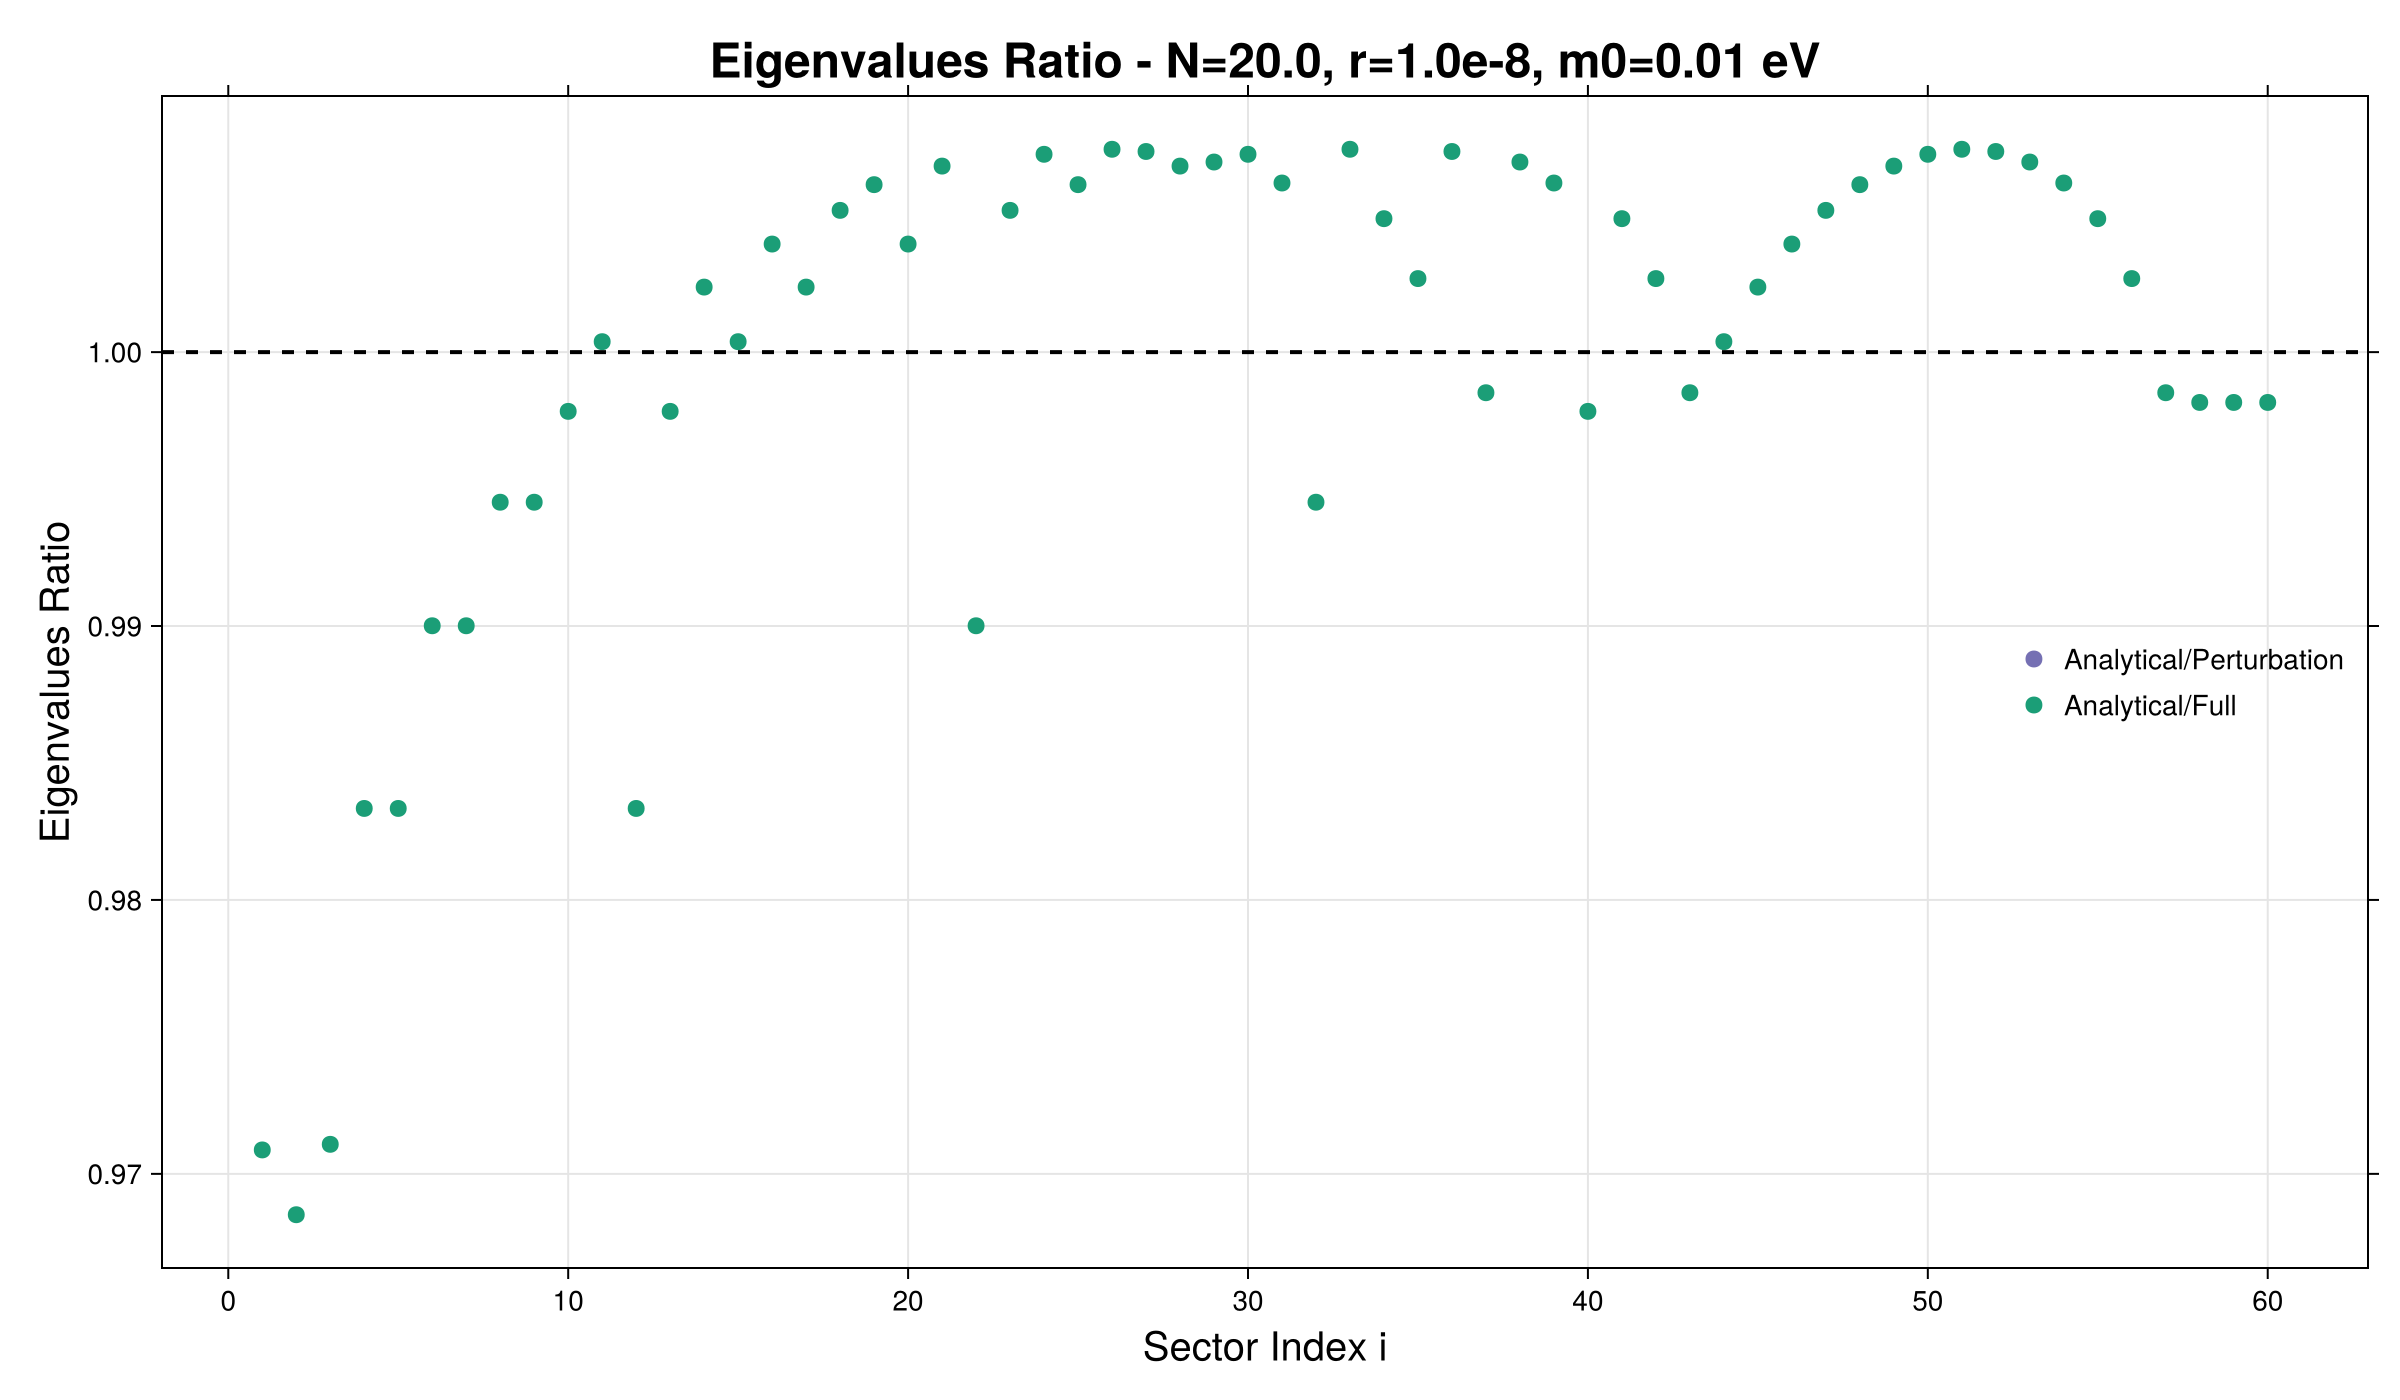

In [51]:

residues_1 = file1 ./ file2
residues_2 =  sort(eigen_analytical)./sort(file1) 
residues_3 =  sort(eigen_analytical)./sort(file2) 


# Dark2_8 palette
palette = cgrad(:Dark2_8, categorical=true)
color_pert_analytical = palette[3]   # blue-ish
color_full_analytical = palette[1]   # green-ish
       # purple-ish (optional)

# Create figure
fig = Figure(resolution=(1200, 700), font="CMU Serif", hgap=10, vgap=10)

title_str = "Eigenvalues Ratio - N=$N, r=$r, m0=$m0 eV"
ax = Axis(fig[1, 1],
    xlabel="Sector Index i",
    ylabel="Eigenvalues Ratio",
    title=title_str,   # plain string
    xticklabelsize=14,
    yticklabelsize=14,
    xlabelsize=20,
    ylabelsize=20,
    titlesize=24,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true,
    #yscale=log10,
)


# Plot scatter points
scatter!(ax, indices1[1:end], residues_3[1:end],
    label="Analytical/Perturbation",
    color=color_pert_analytical,
    markersize=12
)

scatter!(ax, indices2[1:end], residues_2[1:end],
    label="Analytical/Full",
    color=color_full_analytical,
    markersize=12
)

# Horizontal reference line at 1
hlines!(ax, 1, color=:black, linestyle=:dash, linewidth=2)

# Legend
axislegend(ax, position=:rc, framevisible=false, fontsize=20)

# Display or save
save("/home/sofialon/Newtrinos.jl/plots_fix/eigen/eigenvalues_ratio_NNM_NO_$N $r $m0.png", fig)
display("image/png",fig)


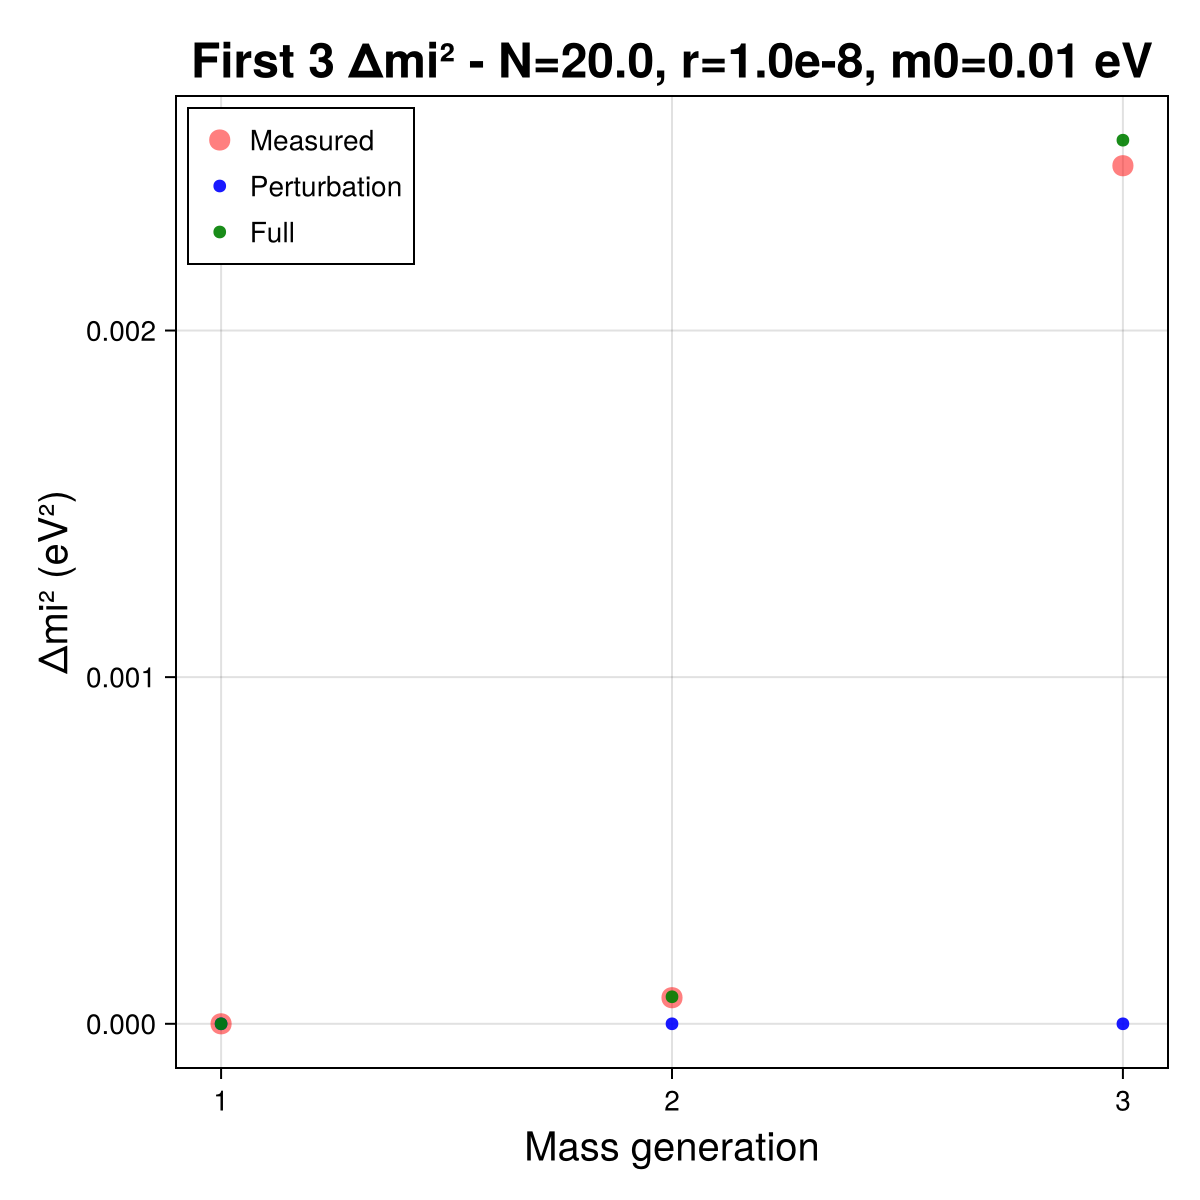

In [52]:

file1 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_fix/eigen/h_full9_NNM_NO_20.0 $r 0.01.txt"))
file2 = vec(readdlm("/home/sofialon/Newtrinos.jl/plots_fix/eigen/h_pert9_NNM_NO_20.0 $r 0.01.txt"))

indices = [1,2,3]


# Create the plot
fig = Figure(size=(600, 600))
ax = Axis(fig[1, 1],
    xlabel="Mass generation",
    ylabel="Δmi² (eV²)",
    title="First 3 Δmi² - N=$N, r=$r, m0=$m0 eV",
    xlabelsize=20,
    ylabelsize=20,
    titlesize=24,
   
)
ax.xticks = 1:3

# Plot scatter points for each file with different colors
scatter!(ax, indices, h_analytical[1:3], label="Measured", markersize=15, alpha=0.5, color=:red)
scatter!(ax, indices, file2[1:3], label="Perturbation", markersize=9, alpha=0.9, color=:blue)

scatter!(ax, indices, file1[1:3], label="Full", markersize=9, alpha=0.9, color=:green)

#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
save("/home/sofialon/Newtrinos.jl/plots_fix/eigen/h_3_NNM_NO_$N $r $m0.png", fig)
display("image/png",fig)


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


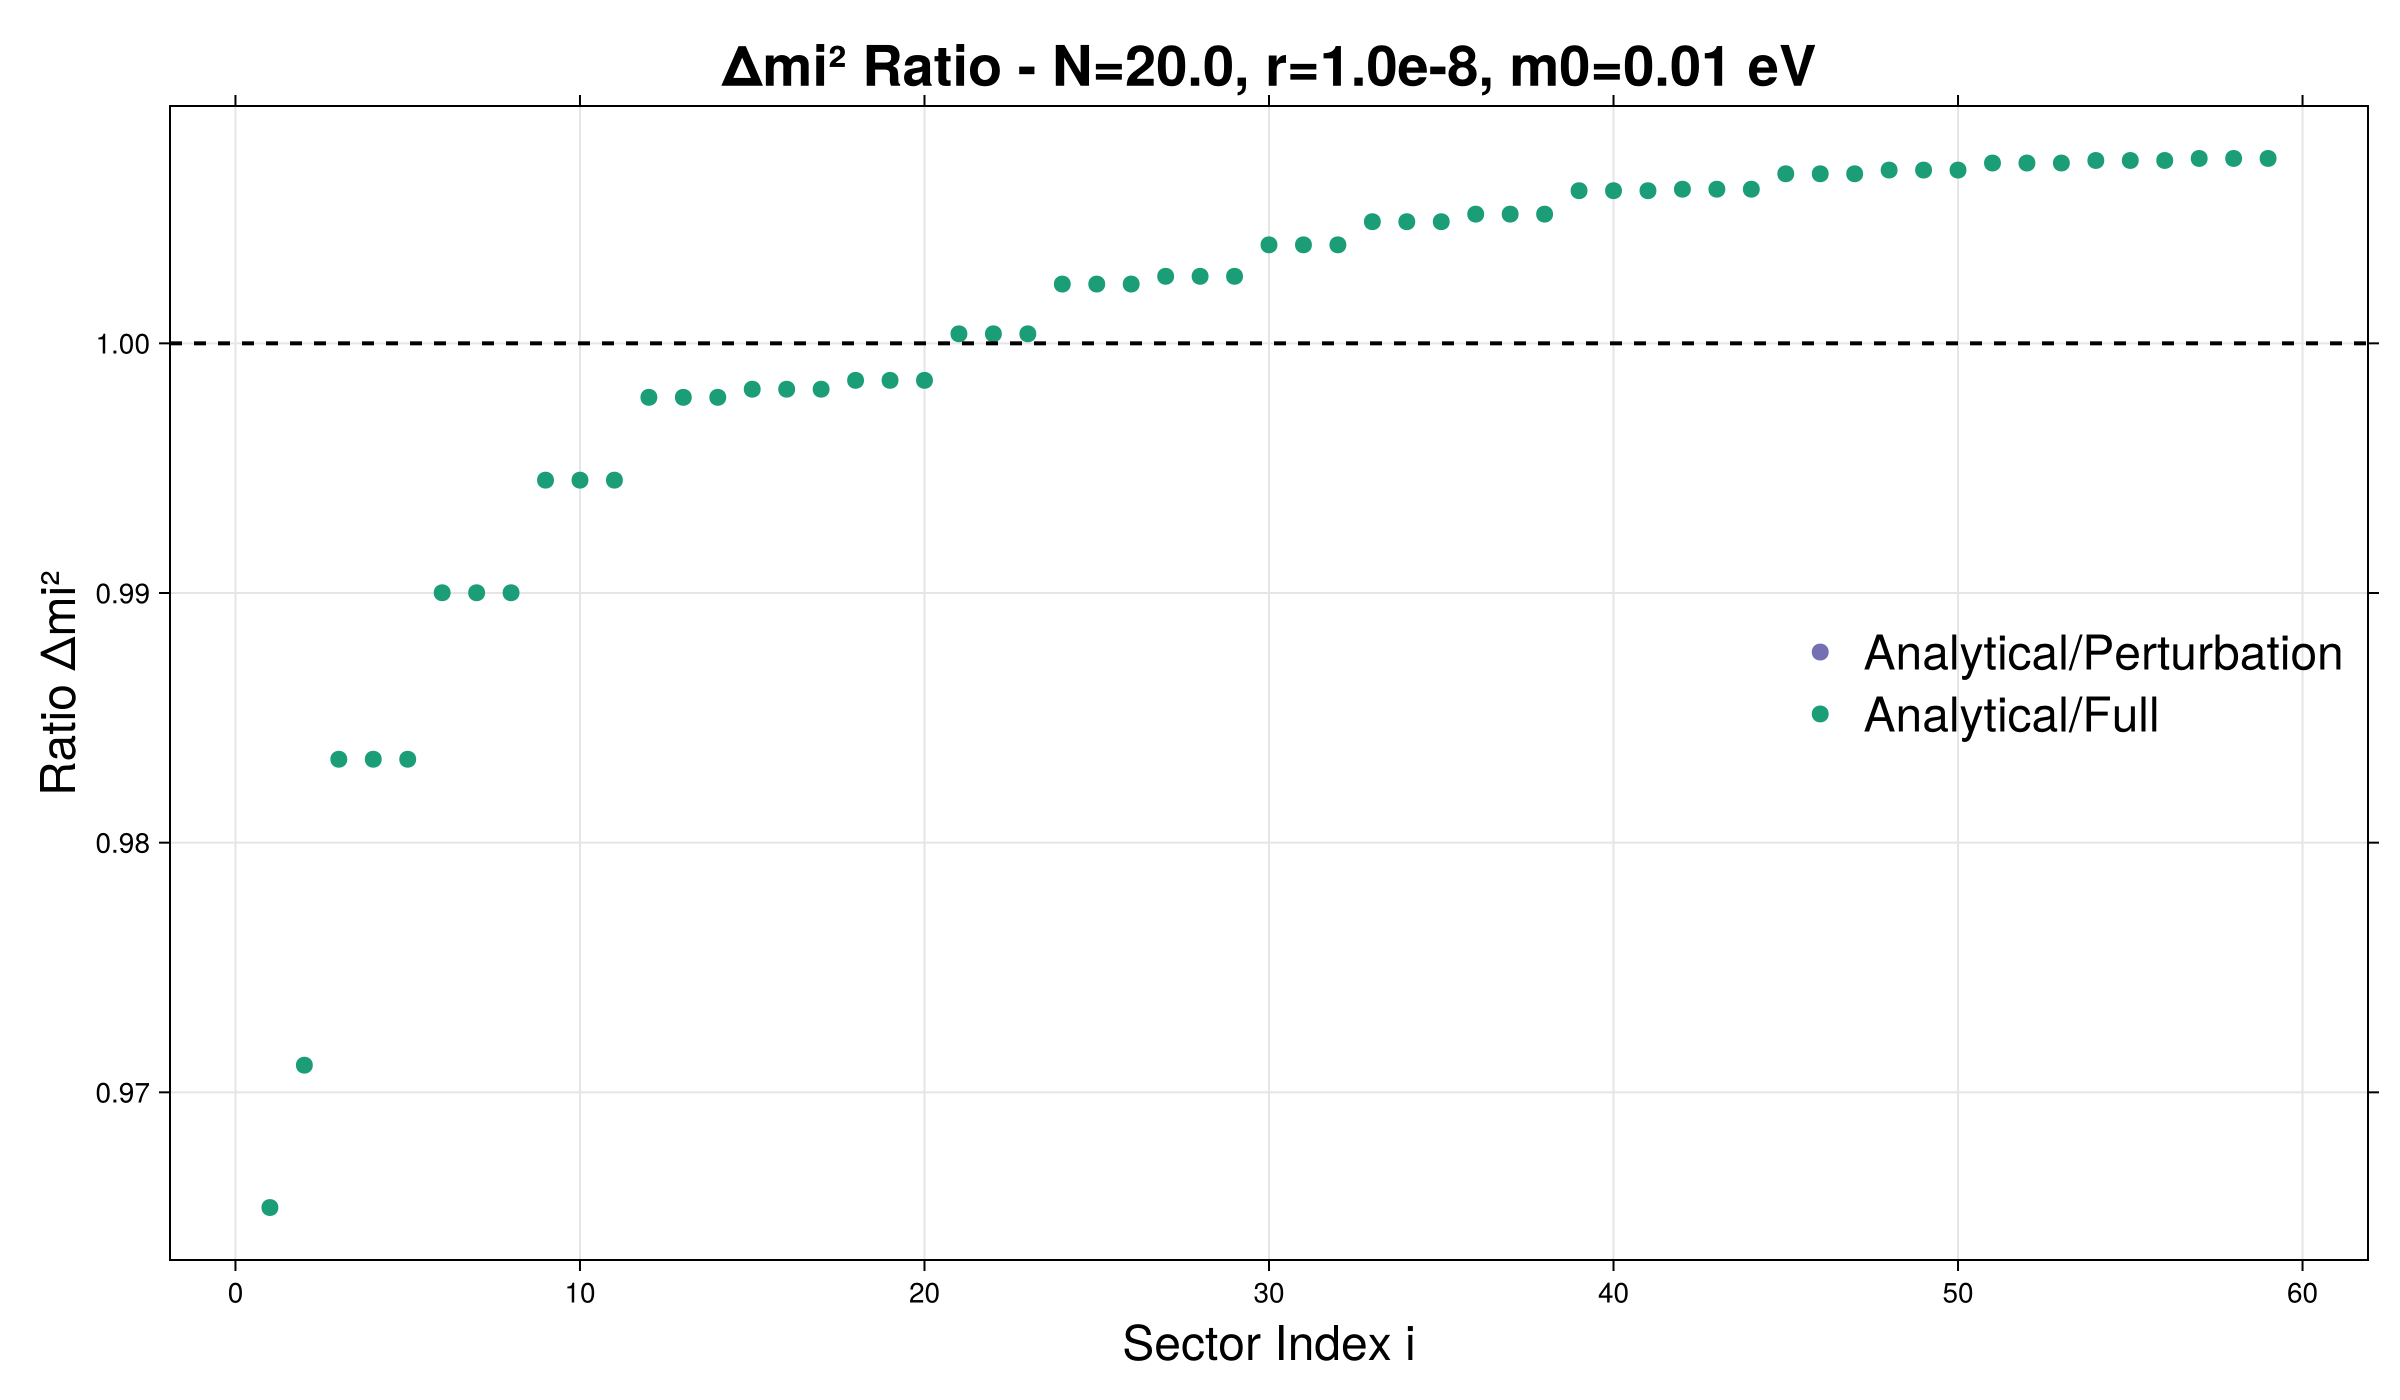

In [53]:


residues_1 = vec(((file1 ./ file2) ))#./ file1) .* 100)
residues_2 = vec(((sort(h_analytical[1:end]./sort(file1))) ))#./ file1) .* 100)
residues_3 = vec(((sort(h_analytical[1:end]./sort(file2)))) )#./ file2) .* 100)
    

# Dark2_8 palette
palette = cgrad(:Dark2_8, categorical=true)
color_pert_analytical = palette[3]   # blue
color_full_analytical = palette[1]   # green

# Title as plain string (safe)
title_str = "Δmi² Ratio - N=$N, r=$r, m0=$m0 eV"

# Create figure
fig = Figure(resolution=(1200, 700), font="CMU Serif", hgap=10, vgap=10)
ax = Axis(fig[1, 1],
    xlabel="Sector Index i",
    ylabel="Ratio Δmi²",
    title= title_str    
    ,   # plain string with LaTeX
    xticklabelsize=14,
    yticklabelsize=14,
    xlabelsize=24,
    ylabelsize=24,
    titlesize=28,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true,
    #yscale=log10,
)

# Scatter plots
scatter!(ax, indices1[1:end], residues_3[1:end],
    label=" Analytical/Perturbation",
    color=color_pert_analytical,
    markersize=12
)

scatter!(ax, indices2[1:end], residues_2[1:end],
    label=" Analytical/Full",
    color=color_full_analytical,
    markersize=12
)

# Optional: perturbation / full
# scatter!(ax, indices1[1:end-3], residues_1[1:end-3],
#     label="Perturbation / Full",
#     color=palette[3],
#     markersize=8
# )

# Horizontal reference line at 1
hlines!(ax, 1, color=:black, linestyle=:dash, linewidth=2)

# Legend
axislegend(ax, position=:rc, framevisible=false, labelsize=24)

# Display or save
save("/home/sofialon/Newtrinos.jl/plots_fix/eigen/h_ratio_NNM_NO_$N $r $m0.png", fig)
display("image/png", fig)


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


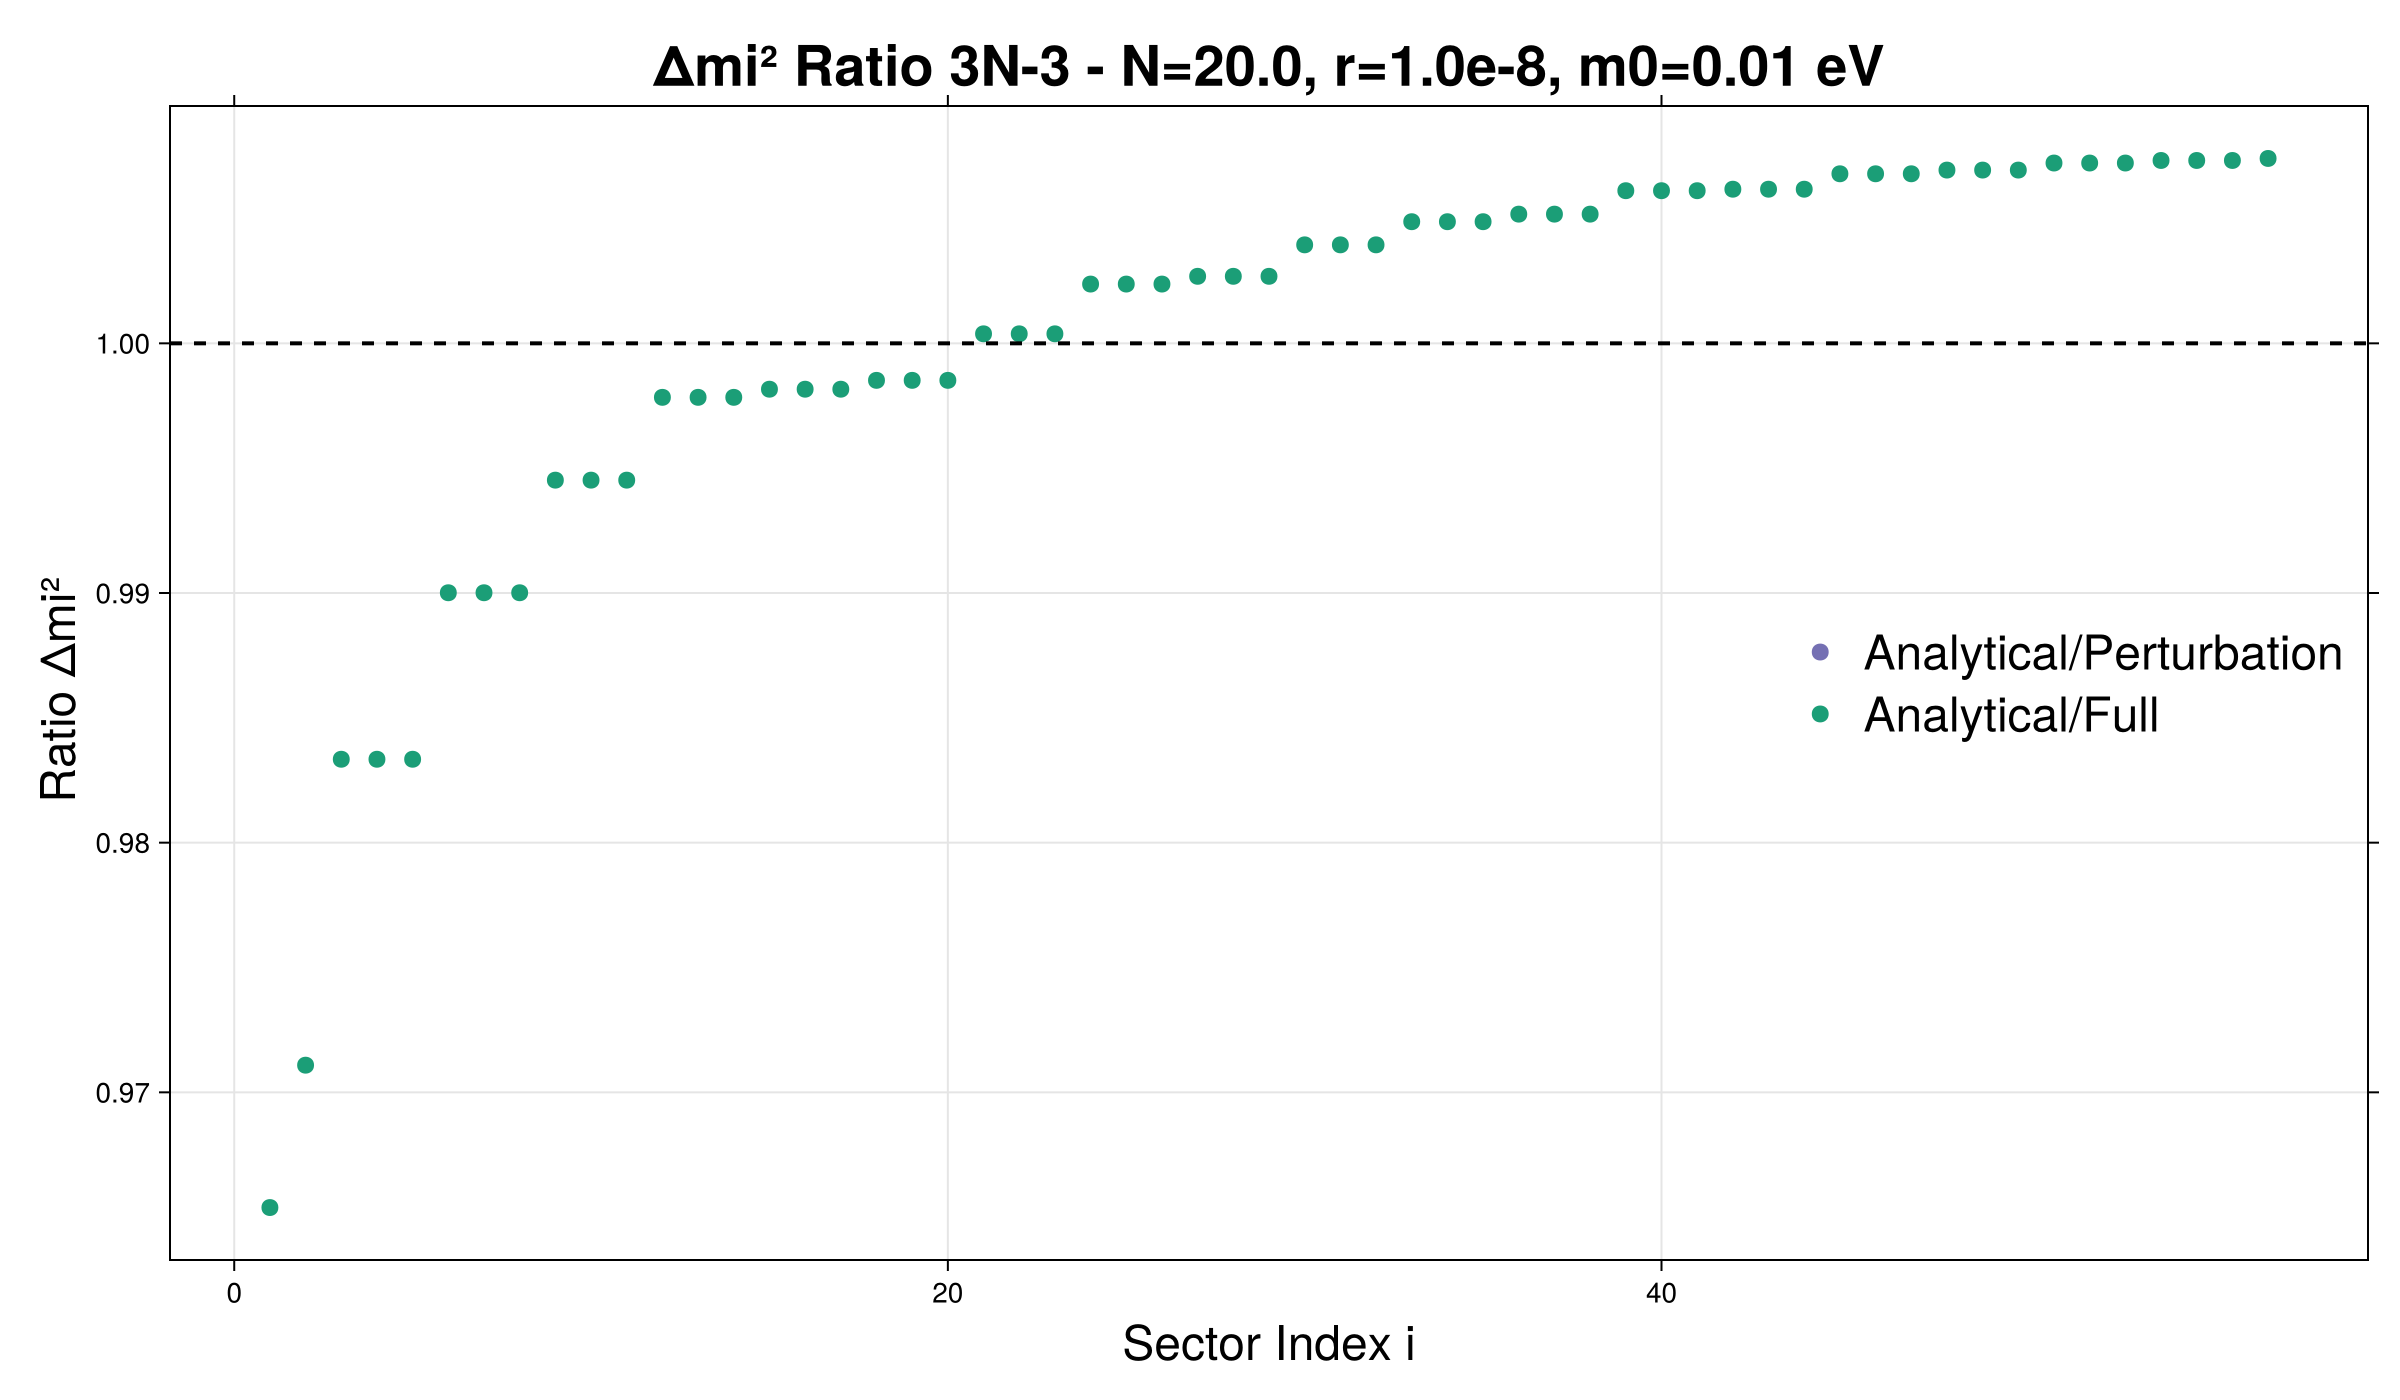

In [54]:


residues_1 = vec(((file1 ./ file2) ))#./ file1) .* 100)
residues_2 = vec(((sort(h_analytical[1:end]./sort(file1))) ))#./ file1) .* 100)
residues_3 = vec(((sort(h_analytical[1:end]./sort(file2)))) )#./ file2) .* 100)
    

# Dark2_8 palette
palette = cgrad(:Dark2_8, categorical=true)
color_pert_analytical = palette[3]   # blue
color_full_analytical = palette[1]   # green

# Title as plain string (safe)
title_str = "Δmi² Ratio 3N-3 - N=$N, r=$r, m0=$m0 eV"

# Create figure
fig = Figure(resolution=(1200, 700), font="CMU Serif", hgap=10, vgap=10)
ax = Axis(fig[1, 1],
    xlabel="Sector Index i",
    ylabel="Ratio Δmi² ",
    title= title_str    
    ,   # plain string with LaTeX
    xticklabelsize=14,
    yticklabelsize=14,
    xlabelsize=24,
    ylabelsize=24,
    titlesize=28,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true,
    #yscale=log10,
)

# Scatter plots
scatter!(ax, indices1[1:end-3], residues_3[1:end-3],
    label=" Analytical/Perturbation",
    color=color_pert_analytical,
    markersize=12
)

scatter!(ax, indices2[1:end-3], residues_2[1:end-3],
    label=" Analytical/Full",
    color=color_full_analytical,
    markersize=12
)

# Optional: perturbation / full
# scatter!(ax, indices1[1:end-3], residues_1[1:end-3],
#     label="Perturbation / Full",
#     color=palette[3],
#     markersize=8
# )

# Horizontal reference line at 1
hlines!(ax, 1, color=:black, linestyle=:dash, linewidth=2)

# Legend
axislegend(ax, position=:rc, framevisible=false, labelsize=24)

# Display or save
save("/home/sofialon/Newtrinos.jl/plots_fix/eigen/h_ratio_NNM_NO_$N $r $m0.png", fig)
display("image/png", fig)
